# Keras
Librería para programar redes neuronales de una manera más sencilla que con TensorFlow. Keras se encuentra en una capa de abstracción por encima de TensorFlow.

[Documentación](https://keras.io/guides/)

In [ ]:
%pip install tensorflow keras           ## instalar sin !, con %. Tarda unos 40 seg.

   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.2/350.8 MB 4.5 MB/s eta 0:01:19
   ---------------------------------------- 0.5/350.8 MB 6.0 MB/s eta 0:00:59
   ---------------------------------------- 1.3/350.8 MB 10.1 MB/s eta 0:00:35
   ---------------------------------------- 1.9/350.8 MB 13.6 MB/s eta 0:00:26
   ---------------------------------------- 2.0/350.8 MB 10.5 MB/s eta 0:00:34
   ---------------------------------------- 4.2/350.8 MB 15.9 MB/s eta 0:00:22
    --------------------------------------- 5.0/350.8 MB 15.8 MB/s eta 0:00:22
    --------------------------------------- 5.8/350.8 MB 16.2 MB/s eta 0:00:22
    --------------------------------------- 6.9/350.8 MB 17.0 MB/s eta 0:00:21
    --------------------------------------- 7.9/350.8 MB 17.3 MB/s eta 0:00:20
   - -------------------------------------- 8.9/350.8 MB 17.8 MB/s eta 0:00:20
   - -------------------------------------- 10.1/350.8 MB 18.5


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
## Si tienes una gráfica Nvidia
# %pip install tensorflow[and-cuda] keras

Empezamos importando librerías

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np

Cargamos los datos de mnist. No vamos a tratar imagenes con redes convolucionales (perdemos la estructura espacial 2D). Todos los pixeles se convertirán en un vector de 28x28 features independientes, que serán las entradas del modelo.

In [3]:
# Cogemos las imágenes de los dígitos asi como el conjunto de train y test
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Vemos dimensiones del dataset

In [5]:
'''
60.000 imagenes de 28x28 pixeles
'''
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
len(np.unique(y_test))          ## 10 numeros distintos

10

In [7]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [8]:
2**8 # niveles de gris

256

60.000 imágenes de 28x28 pixeles. Vamos a representar una de ellas

C:\Users\oscar\AppData\Local\Temp\ipykernel_26224\3096108358.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(X_train[0], cmap=plt.cm.get_cmap('Greys'));


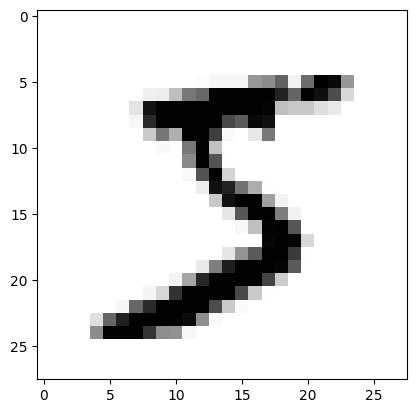

In [9]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap=plt.cm.get_cmap('Greys'));

Cada imagen se compone de 28x28 pixeles, y cada pixel representa una escala de grises que va del 0 al 255. Siendo 0 el blanco y 255 negro.

¿Se te ocurre alguna manera de normalizar los datos?

In [ ]:
np.max(X_train)             ## muchas features, 28*28, 256 valores posibles en cada pixel. 24 millones de features

np.uint8(255)

In [ ]:
0/255               ## escala de grises

0.0

In [12]:
128/255

0.5019607843137255

In [13]:
255/255

1.0

In [14]:
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

In [ ]:
np.mean(X_train)            ## nivel medio de gris

np.float32(0.13066047)

In [16]:
'''
Comprobamos la normalización
'''
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [17]:
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

Guardamos datos para validación. Estos datos se usarán durante el entrenamiento. Otra opción es decirle a keras en la etapa de entrenamiento que reserve un X % de los datos para validar.

In [ ]:
X_val = X_train[-10000:]            ## nos guardamos los 10.000 ultimos datos para test
y_val = y_train[-10000:]

X_train = X_train[:-10000]
y_train = y_train[:-10000]

In [ ]:
print(X_train.shape)            ## 50.000 fotos de 28x28
print(X_val.shape)              ## validation para comprobar overfit, 10.000 fotos
print(X_test.shape)

(50000, 28, 28)
(10000, 28, 28)
(10000, 28, 28)


Montamos la arquitectura de la red neuronal. Se va a componer de:
* **Sequential**: API para iniciar la red neuronal. No cuenta como capa.
* **Flatten**: capa de entrada. Necesita un vector unidimensional. Como tenemos imágenes, esta capa aplana las imagenes (2D) en 1D.
* **Dense**: es una hidden layer. Se compondrá de `n` neuronas y de una función de activación que se aplicará a todas las neuronas de la capa.

Recuerda que es un problema de clasificación multiclase (10 clases) y que por tanto la última capa se compondrá de tantas neuronas como clases tengas.

En cuanto a las funciones de activación es recomendable usar relu en las hidden layer, que tarda menos en entrenar, mientras que la ultima (output) suele ser una softmax.

In [20]:
28*28

784

In [21]:
X_train.shape

(50000, 28, 28)

In [ ]:
model = keras.models.Sequential()           ## modelo secuencial, capa tras capa

# Capa entrada
model.add(keras.layers.Flatten(input_shape=(28, 28)))   ##aplanado, fotos de 28x28

# Hidden layer
model.add(keras.layers.Dense(units = 300,               ## 300 neuronas
                            activation='relu'))

# Hidden layer
model.add(keras.layers.Dense(units = 100,
                            activation='relu'))

# Capa salida
model.add(keras.layers.Dense(units = 10,                ## clasificador de 10 clases, 10 neuronas tantas como clases
                            activation='softmax'))      ## arquitectura de embudo, 300-100-10, pero no siempre es lo mejor. Imita a un cerebro
                                                        ## softmax por ser clasificacion

c:\Users\oscar\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Otra manera de declarar la red neuronal           ##con otra sintaxis...
capas = [
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(units = 300, activation='relu'),
    keras.layers.Dense(units = 100, activation='relu'),
    keras.layers.Dense(units = 10, activation='softmax')
]

model = keras.models.Sequential(capas)

Podemos ver las capas, y acceder a sus elementos

In [ ]:
print(model.layers[0])          ## ver primera capa

<Flatten name=flatten_1, built=True>


Podemos ver los pesos de las capas sin entrenar, porque los inicializa aleatoriamente. Los bias los inicializa a 0.

In [25]:
hidden1 = model.layers[1]
weights, biases = hidden1.get_weights()

In [26]:
weights

array([[-0.05080478,  0.00370906,  0.03617772, ...,  0.05201437,
        -0.01001222,  0.00578499],
       [ 0.03082408,  0.04869277,  0.07121797, ..., -0.0500826 ,
        -0.01315656, -0.04104195],
       [-0.02834828,  0.00815668, -0.01528975, ...,  0.01331077,
         0.01740974, -0.01757071],
       ...,
       [-0.02193406, -0.06046061, -0.05365945, ..., -0.02880569,
         0.05155073,  0.04585475],
       [-0.00371482, -0.01811821, -0.05303726, ..., -0.01738278,
        -0.05136446,  0.05513063],
       [-0.03542906,  0.0569755 ,  0.05414623, ...,  0.06112747,
        -0.04993153,  0.02456503]], shape=(784, 300), dtype=float32)

In [ ]:
len(weights)            ## 784 pesos en toda la red

784

In [ ]:
len(weights[0])         ## peso capa 1, 300

300

In [ ]:
28*28           ## 784 features

784

In [ ]:
300*784         ## 235.200 parametros para ajustar el modelo

235200

In [31]:
weights.size

235200

In [32]:
len(biases)

300

Establecemos la configuración de ejecución... el compile.

In [ ]:
model.compile(
    optimizer = keras.optimizers.SGD(),
    loss = keras.losses.SparseCategoricalCrossentropy(),        ## clasificacion multiclase, sparse...
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)

In [34]:
# Equivalente
model.compile(
    optimizer = "sgd",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
# Summary
model.summary()         ## en la capa de entrada no hay nada, 1 neurona por feature
                        ## 300 neuronas + 235.500 parametros

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
784 * 300 + 300

235500

In [37]:
# 1º neurona de la 1º hidden layer
# y = a + w1*x1 + w2*x2 + .... wn*xn
# a es el intercepto llamado bias
# wn es cada uno de los pesos que va a ir actualizando con el backpropagation
# n es 784
# En la 1º hidden layer tenemos 784 pesos por cada neurona, al tener 300, tenemos un total de:
print(784*300 + 300)

235500


In [38]:
300 * 784 + 300

235500

In [39]:
300 * 100 + 100

30100

In [40]:
100 * 10 + 10

1010

Entrenamos el modelo. Usamos los datos de entrenamiento. El batch_size es la cantidad de muestras que utiliza el SGD, y las epochs son las iteraciones que realiza en el entrenamiento.

In [41]:
X_train.shape

(50000, 28, 28)

In [42]:
50000/128

390.625

In [ ]:
history = model.fit(
    X_train,
    y_train,
    batch_size = 128,           ## tamaño del lote. Se toma como potencia de 2. Lotes de 128, repasados 50 veces (epochs)
    epochs = 50,
    validation_data = (X_val, y_val) # validation_split = 0.1
)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6994 - loss: 1.2406 - val_accuracy: 0.8673 - val_loss: 0.5915
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8720 - loss: 0.5102 - val_accuracy: 0.8996 - val_loss: 0.3917
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8944 - loss: 0.3936 - val_accuracy: 0.9107 - val_loss: 0.3321
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9044 - loss: 0.3453 - val_accuracy: 0.9183 - val_loss: 0.2996
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9111 - loss: 0.3154 - val_accuracy: 0.9228 - val_loss: 0.2787
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9171 - loss: 0.2940 - val_accuracy: 0.9272 - val_loss: 0.2632
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9220 - loss: 0.2766 - val_accuracy: 0.9310 - val_loss: 0.2502
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9260 - loss: 0.2624 - val_accuracy: 0.

Podemos reentrenar el modelo. No empieza de nuevo, sino que retoma el entrenamiento anterior.

In [ ]:
model.fit(
    X_train,
    y_train,
    batch_size = 64,
    epochs = 10,
    validation_data = (X_val, y_val) # validation_split = 0.1       ## no se pierde el entrenamiento anterior de 50 epochs. Transfer learning: tranferir el conocimiento que ha generado otra presona a tu caso particular
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9778 - loss: 0.0826 - val_accuracy: 0.9686 - val_loss: 0.1059
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9786 - loss: 0.0794 - val_accuracy: 0.9706 - val_loss: 0.1027
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9794 - loss: 0.0768 - val_accuracy: 0.9706 - val_loss: 0.1011
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9804 - loss: 0.0740 - val_accuracy: 0.9716 - val_loss: 0.0977
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9816 - loss: 0.0714 - val_accuracy: 0.9719 - val_loss: 0.0976
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9819 - loss: 0.0687 - val_accuracy: 0.9727 - val_loss: 0.0967
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9823 - loss: 0.0664 - val_accuracy: 0.9723 - val_loss: 0.0954
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9834 - loss: 0.0642 - val_accuracy: 0.

Veamos el histórico del entrenamiento, para poder representarlo posteriormente.

In [45]:
# print(history.params)
# print(history.epoch)
print(history.history)

{'accuracy': [0.6994199752807617, 0.8720200061798096, 0.8944399952888489, 0.904420018196106, 0.9110599756240845, 0.9171000123023987, 0.9219599962234497, 0.9259799718856812, 0.9295399785041809, 0.932420015335083, 0.9345999956130981, 0.9372199773788452, 0.9401000142097473, 0.942080020904541, 0.9442600011825562, 0.946120023727417, 0.9480000138282776, 0.9494799971580505, 0.9508200287818909, 0.9526000022888184, 0.9541000127792358, 0.9553800225257874, 0.9563999772071838, 0.9574999809265137, 0.9584199786186218, 0.9598399996757507, 0.961359977722168, 0.9620599746704102, 0.9628599882125854, 0.9639999866485596, 0.9653400182723999, 0.9659199714660645, 0.9667199850082397, 0.9674800038337708, 0.9686400294303894, 0.9693199992179871, 0.9700400233268738, 0.9704200029373169, 0.9714199900627136, 0.9723600149154663, 0.9729400277137756, 0.9735199809074402, 0.9741600155830383, 0.9745200276374817, 0.9751200079917908, 0.9757800102233887, 0.9759200215339661, 0.9768999814987183, 0.9774600267410278, 0.977800011

In [46]:
history.history

{'accuracy': [0.6994199752807617,
  0.8720200061798096,
  0.8944399952888489,
  0.904420018196106,
  0.9110599756240845,
  0.9171000123023987,
  0.9219599962234497,
  0.9259799718856812,
  0.9295399785041809,
  0.932420015335083,
  0.9345999956130981,
  0.9372199773788452,
  0.9401000142097473,
  0.942080020904541,
  0.9442600011825562,
  0.946120023727417,
  0.9480000138282776,
  0.9494799971580505,
  0.9508200287818909,
  0.9526000022888184,
  0.9541000127792358,
  0.9553800225257874,
  0.9563999772071838,
  0.9574999809265137,
  0.9584199786186218,
  0.9598399996757507,
  0.961359977722168,
  0.9620599746704102,
  0.9628599882125854,
  0.9639999866485596,
  0.9653400182723999,
  0.9659199714660645,
  0.9667199850082397,
  0.9674800038337708,
  0.9686400294303894,
  0.9693199992179871,
  0.9700400233268738,
  0.9704200029373169,
  0.9714199900627136,
  0.9723600149154663,
  0.9729400277137756,
  0.9735199809074402,
  0.9741600155830383,
  0.9745200276374817,
  0.9751200079917908,
  0

In [47]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
pd.DataFrame(history.history)       ## accuracy va mejornado segun se hancen mas epochs

,accuracy,loss,val_accuracy,val_loss
0,0.69942,1.240624,0.8673,0.591524
1,0.87202,0.510156,0.8996,0.391701
2,0.89444,0.393614,0.9107,0.332134
3,0.90442,0.345300,0.9183,0.299625
4,0.91106,0.315377,0.9228,0.278686
5,0.91710,0.294050,0.9272,0.263237
6,0.92196,0.276607,0.9310,0.250224
7,0.92598,0.262410,0.9329,0.239041
8,0.92954,0.250169,0.9360,0.228538
9,0.93242,0.238908,0.9376,0.221265


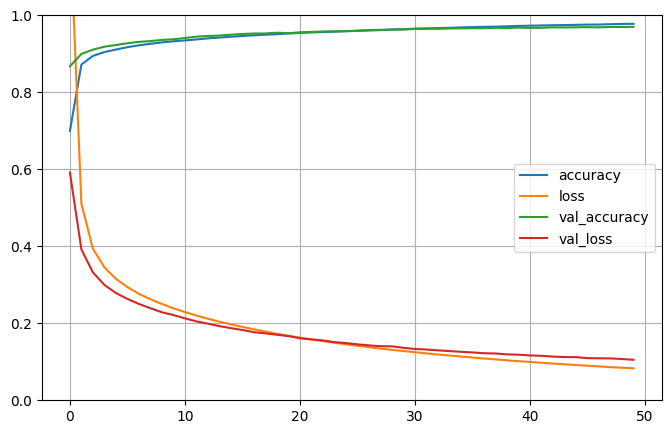

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

Si el modelo no ha ido bien, prueba a cambiar el learning rate, cambia de optimizador y después prueba a cambiar capas, neuronas y funciones de activación.

Ya tenemos el modelo entrenado. Probémoslo con test

In [50]:
results = model.evaluate(X_test, y_test)
results

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9725 - loss: 0.0918


[0.09178196638822556, 0.9725000262260437]

C:\Users\oscar\AppData\Local\Temp\ipykernel_26224\1468152043.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(X_test[0].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));


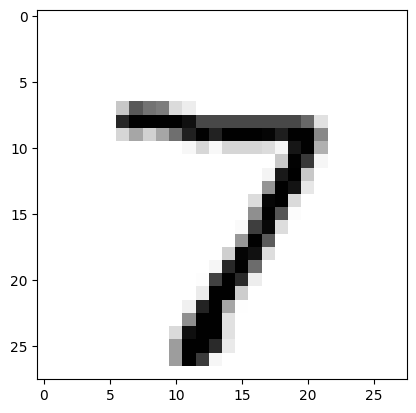

In [51]:
# Cogemos el primero
plt.imshow(X_test[0].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));

In [52]:
X_test[:1]

array([[[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.

In [ ]:
predictions = model.predict(X_test[:1])
print(predictions.shape)
predictions                             ## probabilidades. El del 7 es el mas alto 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
(1, 10)


array([[4.47050616e-06, 2.97104236e-07, 1.66888873e-04, 6.66134758e-04,
        1.05905066e-07, 1.95728785e-06, 1.11488585e-09, 9.99084473e-01,
        4.79777082e-05, 2.76374903e-05]], dtype=float32)

In [54]:
predictions.argmax()

np.int64(7)

In [55]:
model.predict(X_test).argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

C:\Users\oscar\AppData\Local\Temp\ipykernel_26224\4029188365.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(X_test[1].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));


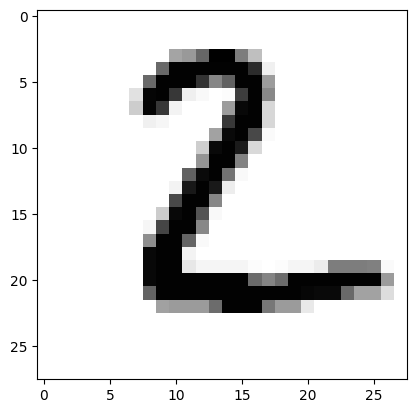

In [56]:
plt.imshow(X_test[1].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, model.predict(X_test).argmax(axis=1))      ## se puede ver qué confunde con qué

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step


array([[ 966,    0,    1,    1,    1,    1,    4,    2,    2,    2],
       [   0, 1125,    3,    0,    0,    1,    2,    1,    3,    0],
       [   4,    3, 1003,    3,    3,    0,    2,    9,    5,    0],
       [   0,    0,    5,  979,    0,    7,    0,    9,    7,    3],
       [   2,    0,    2,    0,  956,    0,    4,    4,    1,   13],
       [   5,    2,    0,    7,    1,  860,    7,    1,    7,    2],
       [   5,    3,    4,    0,    6,    7,  929,    0,    4,    0],
       [   0,    9,    8,    4,    0,    1,    0,  995,    2,    9],
       [   3,    1,    4,    8,    3,    5,    4,    5,  940,    1],
       [   3,    5,    3,    6,    8,    2,    1,    8,    1,  972]])

### Problema de regresión
Veamos un ejemplo de cómo aplicar una red neuronal de TensorFlow a un problema de regresión.

In [58]:
# Cargamos datos
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns = housing.feature_names)
df['target'] = housing['target']
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Divimos en train, test y validation

In [59]:
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data,
                                                              housing.target)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,
                                                      y_train_full)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [60]:
X_train.shape

(11610, 8)

Montamos el modelo. Simplemente se compondrá de una hidden layer, a la que le configuramos una capa previa de entrada de 8 neuronas (las features).

Se trata de un modelo de regresión, por lo que la capa de salida es una única neurona.

In [61]:
11610/32

362.8125

In [62]:
X_train.shape

(11610, 8)

In [63]:
X_train.shape[1:]

(8,)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation = 'relu',                 ## 1 neurona en la salida, por ser regresion, 1 numero solo de salida
                      input_shape = X_train.shape[1:]),
    keras.layers.Dense(1)
])

model.compile(loss = "mean_squared_error",
             optimizer = "sgd")

history = model.fit(X_train,
                   y_train,
                   epochs = 20,
                   validation_data = (X_valid, y_valid))

Epoch 1/20
  1/363 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - loss: 4.5710

c:\Users\oscar\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7662 - val_loss: 0.4931
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: 0.4497 - val_loss: 0.4637
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - loss: 0.4184 - val_loss: 0.4521
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - loss: 0.4064 - val_loss: 0.4072
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - loss: 0.3953 - val_loss: 0.4366
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - loss: 0.3878 - val_loss: 0.4007
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step - loss: 0.3809 - val_loss: 0.3895
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - loss: 0.3807 - val_loss: 0.3833
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - loss: 0.3742 - val_loss: 0.3837
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3698 - val_loss: 0.4274
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - loss: 0.3858 - val_loss: 0.3723
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1

In [ ]:
8*30 + 30           ## 8 features/columnas * 30 neuronas + 30

270

In [66]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303 (1.19 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [67]:
8*30+30

270

In [68]:
mse_test = model.evaluate(X_test, y_test)
print(mse_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step - loss: 0.3903
0.39025792479515076


In [69]:
y_pred = model.predict(X_test[:5])
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[3.5771217 ],
       [1.2672042 ],
       [2.6799889 ],
       [1.1501771 ],
       [0.90100735]], dtype=float32)

### Guardar modelo
Para guardar el modelo, en el formato de Keras (HDF5). 

In [ ]:
model.save("my_keras_model.keras")          ## para guardar el modelo entrenado

In [71]:
# Lo volvemos a cargar
model = keras.models.load_model("my_keras_model.keras")

### Callbacks
Son funciones predefinidas de Keras a aplicar durante el entrenamiento
Por ejemplo, `ModelCheckpoint` sirve para que el modelo se vaya guardando tras cada epoch. Así no perdemos el progreso en caso de que decidamos interrumpir el entrenamiento. El callback recibe como argumento el nombre del objeto donde queremos que se guarde el modelo entrenado.

In [72]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("callback_model.keras")
history = model.fit(X_train,
                   y_train,
                   epochs=30,
                   callbacks = [checkpoint_cb])

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step - loss: 0.3602
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - loss: 0.3573
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - loss: 0.3527
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step - loss: 0.3490
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - loss: 0.3496
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step - loss: 0.3464
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step - loss: 0.3435
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step - loss: 0.3438
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step - loss: 0.3424
Epoch 10/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step - loss: 0.3475
Epoch 11/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - loss: 0.3372
Epoch 12/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 0.3416
Epoch 13/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - loss: 0.3371
Epoch 14/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - loss: 0.3359
Epoch 15/30
363/363 ━━━━━━━━━

### Early Stopping
Interrumpe el entrenamiento cuando no ve progreso en el set de validación. Para ello tiene en cuenta un numero de epochs llamado `patience`. Se puede combinar con el callback

In [ ]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10)      ## early stopping de 10, haz 10 iteraciones donde no se mejore antes de parar
history = model.fit(X_train,
                   y_train,
                   epochs=50,
                   validation_data = (X_valid, y_valid),
                   callbacks = [early_stopping_cb, checkpoint_cb])      ## checkpoint guarda el modelo si se peta el ordenador

Epoch 1/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3234 - val_loss: 0.3297
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3309 - val_loss: 0.3441
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3235 - val_loss: 0.3477
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3196 - val_loss: 0.3510
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3183 - val_loss: 0.3293
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3190 - val_loss: 0.3334
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3234 - val_loss: 0.3406
Epoch 8/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3171 - val_loss: 0.3296
Epoch 9/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3161 - val_loss: 0.3310
Epoch 10/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3164 - val_loss: 0.3372
Epoch 11/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3210 - val_loss: 0.3291
Epoch 12/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

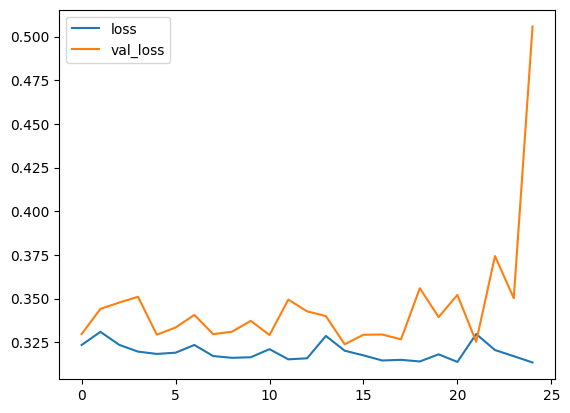

In [74]:
history_df = pd.DataFrame(history.history).plot()